# Ross Ex. 13

Let ${X_1, \cdots, X_n}$ be independent and identically distributed random variables
having unknown mean $\mu$. For given constants $a < b$, we are interested in
estimating

$$p = P(a < \sum^{n}_{i = 1} \dfrac{X_i}{n} − \mu < b)$$

(a) Explain how we can use the bootstrap approach to estimate p.

(b) Estimate p if n = 10 and the values of the X i are 56, 101, 78, 67, 93, 87,
64, 72, 80, and 69. Take a = − 5, b = 5.

### (a) Bootstrap approach

We don't know $\mu$, so $\bar X - \mu$ can't be computed directly from the data. The
bootstrap replaces the unknown pair (true distribution $F$, true mean $\mu$) by the
*empirical* pair (empirical distribution $F_n$ given by the observed sample, sample
mean $\bar x$):

1. Compute the sample mean $\bar x = \frac{1}{n}\sum_i x_i$ from the original data.
2. Draw $B$ bootstrap samples $x_1^{*},\dots,x_n^{*}$, each obtained by sampling
   $n$ values **with replacement** from $\{x_1,\dots,x_n\}$.
3. For each bootstrap sample compute the bootstrap mean $\bar x^{*}$. The quantity
   $\bar x^{*} - \bar x$ is the bootstrap analogue of $\bar X - \mu$ (resampling from
   $F_n$ with "true mean" $\bar x$, just as the original data is sampled from $F$
   with true mean $\mu$).
4. Estimate $p$ by the fraction of bootstrap replications that fall in $(a,b)$:

$$\hat p = \frac{1}{B}\sum_{j=1}^{B} \mathbb{1}\{a < \bar x^{*}_j - \bar x < b\}$$

### (b) Numerical estimate

Sample mean x_bar = 76.70
Bootstrap estimate: p_hat = P(-5 < X_bar - mu < 5) = 0.7650


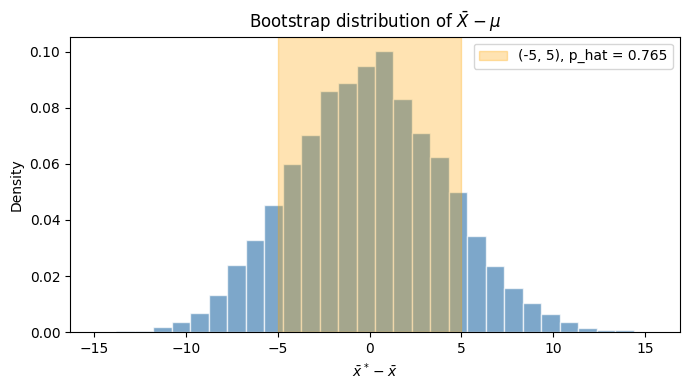

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Ex (b): bootstrap estimate of p = P(a < X_bar - mu < b)
np.random.seed(42)

X = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
n = len(X)
a, b = -5, 5
B = 10000

x_bar = X.mean()

boot_samples = np.random.choice(X, size=(B, n), replace=True)
boot_means = boot_samples.mean(axis=1)
boot_diffs = boot_means - x_bar

p_hat = np.mean((a < boot_diffs) & (boot_diffs < b))

print(f"Sample mean x_bar = {x_bar:.2f}")
print(f"Bootstrap estimate: p_hat = P({a} < X_bar - mu < {b}) = {p_hat:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_diffs, bins=30, density=True, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvspan(a, b, color="orange", alpha=0.3, label=f"({a}, {b}), p_hat = {p_hat:.3f}")
ax.set_xlabel(r"$\bar x^* - \bar x$")
ax.set_ylabel("Density")
ax.set_title("Bootstrap distribution of $\\bar X - \\mu$")
ax.legend()
fig.tight_layout()
plt.show()

# Ross Ex. 15
If n = 15 and the data are 5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8 approximate (by a simulation) the bootstrap estimate of Var($S^2$).

**Bootstrap estimate of $\mathrm{Var}(S^2)$:** resample $n$ values **with replacement**
from the data to get $x_1^{*},\dots,x_n^{*}$, compute the bootstrap sample variance

$$S^{*2} = \frac{1}{n-1}\sum_{i=1}^n (x_i^{*} - \bar x^{*})^2,$$

and repeat this $B$ times to get $S^{*2}_1,\dots,S^{*2}_B$. Approximate
$\mathrm{Var}(S^2)$ by the empirical variance of these replications:

$$\widehat{\mathrm{Var}}(S^2) = \frac{1}{B}\sum_{j=1}^{B}\left(S^{*2}_j - \overline{S^{*2}}\right)^2$$

Sample variance S^2:            34.3143
Bootstrap estimate of Var(S^2): 59.1394


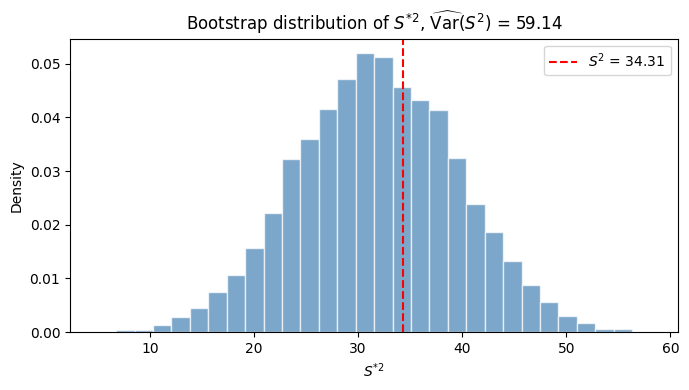

In [5]:
# Ex 15: bootstrap estimate of Var(S^2)
np.random.seed(42)

data = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])
n = len(data)
B = 10000

S2 = data.var(ddof=1)

boot_samples = np.random.choice(data, size=(B, n), replace=True)
boot_S2 = boot_samples.var(axis=1, ddof=1)

var_S2_hat = boot_S2.var()

print(f"Sample variance S^2:            {S2:.4f}")
print(f"Bootstrap estimate of Var(S^2): {var_S2_hat:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot_S2, bins=30, density=True, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(S2, color="r", ls="--", label=f"$S^2$ = {S2:.2f}")
ax.set_xlabel(r"$S^{*2}$")
ax.set_ylabel("Density")
ax.set_title(r"Bootstrap distribution of $S^{*2}$, $\widehat{\mathrm{Var}}(S^2)$" + f" = {var_S2_hat:.2f}")
ax.legend()
fig.tight_layout()
plt.show()

## Bootstrap variance of the sample mean vs. the sample median

Write a program that takes a sample as input and returns the sample median together
with a bootstrap estimate of the variance of the median, based on $k = 100$
bootstrap replicates. Run it on a sample of $n = 200$ Pareto($\beta=1$, $k=1.05$)
observations.

1. Compute the sample mean and sample median.
2. Estimate the variance of the sample mean using the bootstrap method.
3. Estimate the variance of the sample median using the bootstrap method.
4. Compare the precision of the two estimators.
5. Explain the observed differences in terms of the underlying distribution.

A Pareto($\beta,k$) variable can be generated by inversion: if $U\sim\mathrm{Unif}(0,1)$
then $X = \beta\, U^{-1/k} \sim \mathrm{Pareto}(\beta,k)$, since
$P(X>x) = P(U < (\beta/x)^k) = (\beta/x)^k$.

In [ ]:
def pareto_sample(beta, k, size):
    U = np.random.uniform(size=size)
    return beta * U ** (-1.0 / k)

def bootstrap_variance(sample, stat_fn, B):
    """Bootstrap estimate of Var(stat_fn(sample)) from B resamples of the same size as 'sample'."""
    n = len(sample)
    boot_samples = np.random.choice(sample, size=(B, n), replace=True)
    return stat_fn(boot_samples, axis=1).var(ddof=1)

def median_with_bootstrap_variance(sample, B=100):
    """Return (sample median, bootstrap estimate of Var(median)) based on B replicates."""
    return np.median(sample), bootstrap_variance(sample, np.median, B)

np.random.seed(42)

beta, k = 1.0, 1.05
n = 200
B = 100

sample = pareto_sample(beta, k, n)

sample_mean = sample.mean()
sample_median, var_median_hat = median_with_bootstrap_variance(sample, B)
var_mean_hat = bootstrap_variance(sample, np.mean, B)

print(f"Theoretical mean   (k beta/(k-1)): {k * beta / (k - 1):.4f}")
print(f"Theoretical median (beta 2^(1/k)): {beta * 2 ** (1 / k):.4f}\n")

print(f"Sample mean:   {sample_mean:.4f}")
print(f"Sample median: {sample_median:.4f}\n")

print(f"Bootstrap Var(mean):   {var_mean_hat:.4f}  (SE = {np.sqrt(var_mean_hat):.4f})")
print(f"Bootstrap Var(median): {var_median_hat:.4f}  (SE = {np.sqrt(var_median_hat):.4f})\n")

print(f"Var(mean) / Var(median): {var_mean_hat / var_median_hat:.2f}")

Theoretical mean   (k beta/(k-1)): 21.0000
Theoretical median (beta 2^(1/k)): 1.9351

Sample mean:   5.4722
Sample median: 1.9556

Bootstrap Var(mean):   0.9296  (SE = 0.9642)
Bootstrap Var(median): 0.0540  (SE = 0.2324)

Var(mean) / Var(median): 17.21


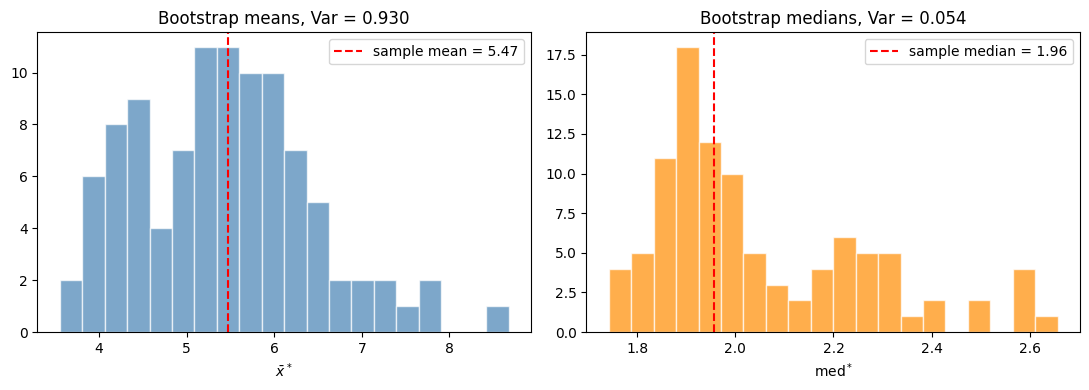

In [7]:
# Visualize the bootstrap distributions of the mean and the median
boot_samples = np.random.choice(sample, size=(B, n), replace=True)
boot_means = boot_samples.mean(axis=1)
boot_medians = np.median(boot_samples, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(boot_means, bins=20, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].axvline(sample_mean, color="r", ls="--", label=f"sample mean = {sample_mean:.2f}")
axes[0].set_title(f"Bootstrap means, Var = {var_mean_hat:.3f}")
axes[0].set_xlabel(r"$\bar x^*$")
axes[0].legend()

axes[1].hist(boot_medians, bins=20, color="darkorange", alpha=0.7, edgecolor="white")
axes[1].axvline(sample_median, color="r", ls="--", label=f"sample median = {sample_median:.2f}")
axes[1].set_title(f"Bootstrap medians, Var = {var_median_hat:.3f}")
axes[1].set_xlabel(r"$\mathrm{med}^*$")
axes[1].legend()

fig.tight_layout()
plt.show()

### Discussion

**4. Precision.** The bootstrap variance of the sample mean is roughly **17 times
larger** than that of the sample median (and the sample mean itself, $\approx 5.5$,
is far from the true mean $21$, while the sample median, $\approx 1.96$, is very
close to the true median $\approx 1.94$). The median is by far the more precise and
more reliable estimator of central tendency here.

**5. Why.** For Pareto($\beta,k$) the variance is

$$\mathrm{Var}(X) = \frac{k\beta^2}{(k-1)^2(k-2)}, \qquad k>2,$$

which is **infinite** for $k=1.05 \le 2$ (even the mean is only barely finite, since
it requires $k>1$). The sample mean is dominated by the occasional extremely large
observation drawn from the heavy right tail, so its sampling distribution is highly
skewed and spread out -- and the bootstrap, which resamples from those same extreme
values, faithfully reproduces this huge variability.

The sample median, in contrast, only depends on the *order* of the observations
near the centre of the data, not on how extreme the tail values are. Its asymptotic
variance, $\mathrm{Var}(\mathrm{med}) \approx \frac{1}{4 n f(m)^2}$ where $f$ is the
density at the true median $m$, is finite for any continuous distribution with
positive density at the median -- regardless of how heavy the tails are. This is why
the median is a much more stable (robust) estimator for heavy-tailed distributions
like this Pareto.